# Business Analytics Project

This notebook contains a synthetic dataset simulating quarterly business performance across regions. We perform exploratory data analysis (EDA) to understand the distribution of variables, relationships between features, and develop predictive models to forecast revenue and profitability.

The synthetic dataset includes features such as marketing spend, economic and competition indices, product prices, sales volumes, returned items, customer satisfaction scores, and region information. We calculate revenue and profit based on these features and create a binary classification label indicating whether a scenario was profitable.

We demonstrate:
- Reading and exploring the dataset
- Visualizing distributions and relationships
- Building a regression model to predict revenue
- Building a classification model to predict profitability (Is_Profit)


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

# Load dataset
file_path = 'data/business_data.csv'
df = pd.read_csv(file_path)

# Display first few rows
print('Dataset shape:', df.shape)
df.head()


Matplotlib is building the font cache; this may take a moment.


Dataset shape: (500, 13)


,Month,Season,Marketing_Spend,Economic_Index,Competition_Index,Product_Price,Sales_Volume,Returned_Items,Customer_Satisfaction,Region,Revenue,Profit,Is_Profit
0,7,Spring,56990,0.558130,0.255275,114.841659,200,8,10,West,22049.598604,-34940.401396,0
1,4,Spring,55998,0.745493,0.737143,103.748398,212,13,2,South,20645.931124,-35352.068876,0
2,11,Winter,45187,0.637159,0.284425,127.253477,187,13,1,West,22142.105041,-23044.894959,0
3,8,Summer,29062,0.588160,0.316664,83.369961,193,13,2,West,15006.593005,-14055.406995,0
4,5,Winter,45799,0.577499,0.346635,97.868105,224,7,7,East,21237.378738,-24561.621262,0


In [2]:

# Summary statistics and basic info
summary = df.describe(include='all')
summary


,Month,Season,Marketing_Spend,Economic_Index,Competition_Index,Product_Price,Sales_Volume,Returned_Items,Customer_Satisfaction,Region,Revenue,Profit,Is_Profit
count,500.000000,500,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500,500.000000,500.000000,500.000000
unique,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN
top,NaN,Winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,East,NaN,NaN,NaN
freq,NaN,144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128,NaN,NaN,NaN
mean,6.504000,NaN,50626.082000,0.605509,0.496588,101.832923,200.490000,11.250000,5.664000,NaN,19271.155294,-31354.926706,0.004000
std,3.543317,NaN,10827.085023,0.103319,0.150216,20.041331,14.239502,4.796824,2.996174,NaN,4043.835021,11679.360464,0.063182
min,1.000000,NaN,14317.000000,0.328751,-0.008264,41.969526,166.000000,3.000000,1.000000,NaN,6673.154689,-65297.600494,0.000000
25%,3.000000,NaN,43660.500000,0.543296,0.396487,88.884351,190.750000,7.000000,3.000000,NaN,16632.230035,-38706.830164,0.000000
50%,7.000000,NaN,50999.000000,0.608278,0.489907,102.886876,200.000000,11.000000,6.000000,NaN,19370.747872,-31079.003552,0.000000
75%,10.000000,NaN,57574.000000,0.675402,0.601796,114.307857,210.000000,15.000000,8.000000,NaN,21956.056894,-23464.247924,0.000000


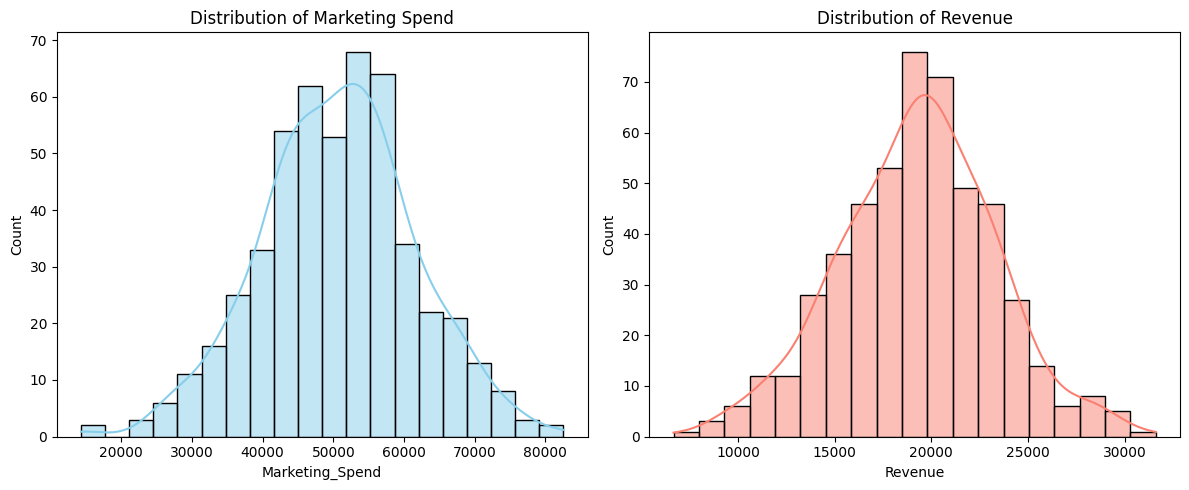

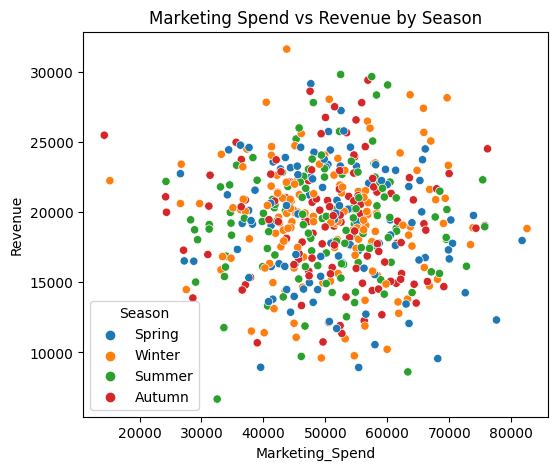

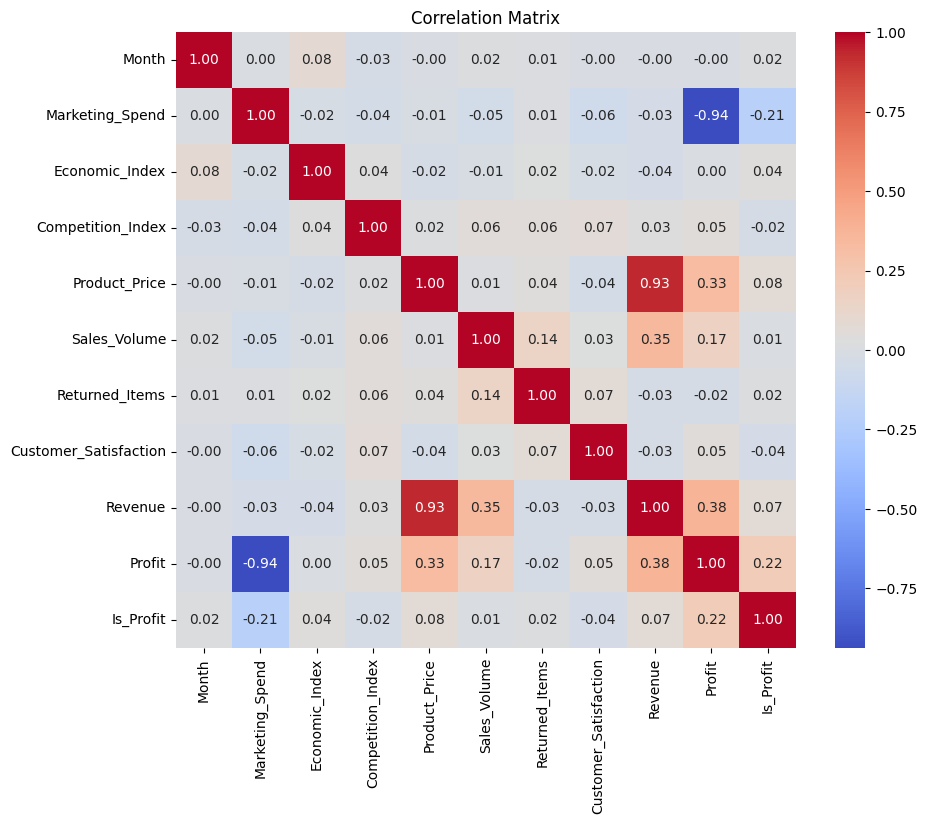

In [3]:

# Histograms for Marketing_Spend and Revenue
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Marketing_Spend'], kde=True, color='skyblue')
plt.title('Distribution of Marketing Spend')
plt.subplot(1,2,2)
sns.histplot(df['Revenue'], kde=True, color='salmon')
plt.title('Distribution of Revenue')
plt.tight_layout()
plt.show()

# Scatter plot
plt.figure(figsize=(6,5))
sns.scatterplot(x='Marketing_Spend', y='Revenue', data=df, hue='Season')
plt.title('Marketing Spend vs Revenue by Season')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
cor = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(cor, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [4]:

# Regression model to predict Revenue
# Preprocess: One-hot encode categorical variables
X = pd.get_dummies(df.drop(['Revenue','Profit','Is_Profit'], axis=1), drop_first=True)
y = df['Revenue']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit linear regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = lin_reg.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print('Linear Regression MSE:', mse)


Linear Regression MSE: 90421.13779658267


In [5]:

# Classification model to predict Is_Profit
X_cls = pd.get_dummies(df.drop(['Revenue','Profit','Is_Profit'], axis=1), drop_first=True)
y_cls = df['Is_Profit']

# Split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Standardize
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_c_scaled, y_train_c)

# Predict and evaluate
cls_pred = log_reg.predict(X_test_c_scaled)
acc = accuracy_score(y_test_c, cls_pred)
print('Classification Accuracy:', acc)

# Detailed report
report = classification_report(y_test_c, cls_pred)
print(report)


Classification Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



## Conclusion

This notebook generated a synthetic business dataset and performed exploratory data analysis to understand distributions and relationships. We implemented a linear regression model to forecast revenue and achieved a mean squared error value as reported above. Additionally, we built a logistic regression classifier to predict whether a scenario is profitable (Is_Profit) and evaluated the model using accuracy and a classification report. These techniques demonstrate fundamental skills applicable to business analytics, program management, and data analysis roles.